#EDA

---



In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Merge data/fb_comments.csv'

df = pd.read_csv(file_path)

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13640 entries, 0 to 13639
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   komen_fb  13424 non-null  object
dtypes: object(1)
memory usage: 106.7+ KB


(13640, 1)

In [5]:
df.head()

,komen_fb
0,Tuntutan dalam 7 HARI KEDEPAN:
1,"Kalau ada pejabat yg KORUPSI, Jangan harap lg..."
2,"Para pejabat publik sering pamer harta benda, ..."
3,Drpada fasilitas umum dan pertokoan ya mending...
4,"Hahaha it's hilarious, rampok dirampok"


##Analisis Missing Values

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df)) * 100
})

print(missing_df)

   Jumlah Missing  Persentase (%)
0             216        1.583578


##Analisis Duplicate Data

In [7]:
duplicate_count = df['komen_fb'].duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")


duplicates = df[df.duplicated()]
print(duplicates[['komen_fb']])

Jumlah data duplikat: 688
            komen_fb
297           Mantap
326           Mantap
332    Alhamdulillah
360           Maling
414    Alhamdulillah
...              ...
13623            NaN
13625            NaN
13635  Next Uya Kuya
13636            NaN
13639         Mantap

[688 rows x 1 columns]


##Analisis Noise

In [8]:
# Pastikan data string
df.columns = df.columns.str.strip()

print(df.columns)

Index(['komen_fb'], dtype='object')


Deteksi URL

In [9]:
import re

url_pattern = r'http\S+|www\S+'

df['contains_url'] = df['komen_fb'].apply(
    lambda x: bool(re.search(url_pattern, str(x)))
)

print(df['contains_url'].value_counts())

print(df[df['contains_url']]['komen_fb'].head())

contains_url
False    13636
True         4
Name: count, dtype: int64
493      https://rmol.id/publika/read/2025/08/29/678057...
5285     https://www.tokopedia.com/riyansukses/celana-m...
7365     https://rmol.id/politik/read/2025/08/31/678298...
11813                                              Aswwwww
Name: komen_fb, dtype: object


Deteksi Hashtag

In [10]:
hashtag_pattern = r'#\w+'

df['contains_hashtag'] = df['komen_fb'].apply(
    lambda x: bool(re.search(hashtag_pattern, str(x)))
)

print(df['contains_hashtag'].value_counts())

print(df[df['contains_hashtag']]['komen_fb'])

contains_hashtag
False    13634
True         6
Name: count, dtype: int64
604     Lengserkan #KAPOLRI selama ini juga bawahan-ba...
6381                                         #Orang #baik
6727    : #1.Utk lbh independent, bgmn kl agt MPR tdk ...
7635    Harus ditangkap ya betul saya sangat setuju yg...
9037    Coba dipikir dengan jernih,selama Indonesia le...
9335    Begitupun aparat negara jika melanggar etika h...
Name: komen_fb, dtype: object


Deteksi Mention

In [11]:
mention_pattern = r'@\w+'

df['contains_mention'] = df['komen_fb'].apply(
    lambda x: bool(re.search(mention_pattern, str(x)))
    if pd.notnull(x) else False
)

print(df['contains_mention'].value_counts())

df[df['contains_mention']]

contains_mention
False    13635
True         5
Name: count, dtype: int64


,komen_fb,contains_url,contains_hashtag,contains_mention
3100,"ditunggu...nex @uya Kuya,@eko Patrio...",False,False,True
3570,Mas @ekopatrio @uya kuya siap2,False,False,True
7297,Kalau secara Damai gak akan didengar bapak Pre...,False,False,True
7471,Copot semua menteri polri dll yg ada kait@nnya...,False,False,True
10501,Ini peringatan kepada semua wakil rakyat supay...,False,False,True


Deteksi Emoji

In [12]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticon
    u"\U0001F300-\U0001F5FF"  # simbol & pictograph
    u"\U0001F680-\U0001F6FF"  # transport
    u"\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

df['contains_emoji'] = df['komen_fb'].apply(
    lambda x: bool(emoji_pattern.search(str(x)))
)

print(df['contains_emoji'].value_counts())

print(df[df['contains_emoji']]['komen_fb'])

contains_emoji
False    13640
Name: count, dtype: int64
Series([], Name: komen_fb, dtype: object)


Deteksi Simbol Berlebih

In [13]:
symbol_pattern = r'[^\w\s]'

df['contains_symbol'] = df['komen_fb'].apply(
    lambda x: bool(re.search(symbol_pattern, str(x)))
)

print(df['contains_symbol'].value_counts())

print(df[df['contains_symbol']]['komen_fb'].head())

contains_symbol
True     7801
False    5839
Name: count, dtype: int64
0                       Tuntutan dalam 7 HARI KEDEPAN:
1    Kalau ada pejabat yg  KORUPSI, Jangan harap lg...
2    Para pejabat publik sering pamer harta benda, ...
3    Drpada fasilitas umum dan pertokoan ya mending...
4              Hahaha  it's hilarious, rampok dirampok
Name: komen_fb, dtype: object


Deteksi Karakter Berulang
*   baguusssss
*   mantapppp



In [14]:
repeat_pattern = r'(.)\1{4,}'

df['contains_repeated_char'] = df['komen_fb'].apply(
    lambda x: bool(re.search(repeat_pattern, str(x).lower()))
)

print(df['contains_repeated_char'].value_counts())

print(df[df['contains_repeated_char']]['komen_fb'].head())


contains_repeated_char
False    13215
True       425
Name: count, dtype: int64
13    Mantaaaaaap ...  Cara Rakyat .... Perampasan a...
24    Kl kalian menjarah itu sama aja maling lebih b...
26    Jangan di lewatkan juga yg kena korupsi gasss ...
49    Peramokan massal  dan itu katanya halal..........
96                          Revolusi Harga Mati.....!!!
Name: komen_fb, dtype: object


Deteksi Teks Irrelevant
*   terlalu pendek
*   hanya angka/simbol



In [15]:
def irrelevant_text(text):

    text = str(text).strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya angka/simbol
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

df['irrelevant_text'] = df['komen_fb'].apply(irrelevant_text)

print(df['irrelevant_text'].value_counts())

print(df[df['irrelevant_text']]['komen_fb'])

irrelevant_text
False    13630
True        10
Name: count, dtype: int64
496      +62 853-7933-2830
591                      .
5439                    Oh
9845                    Ni
10069                 !  !
11659                   67
12112                   No
12220                   ..
12393                   mq
12438                    7
Name: komen_fb, dtype: object


Ringkasan Noise


===== RINGKASAN NOISE =====
          Jenis Noise  Jumlah
0          URL/Tautan       4
1             Hashtag       6
2             Mention       5
3   Karakter Berulang     425
4  Teks Tidak Relevan      10


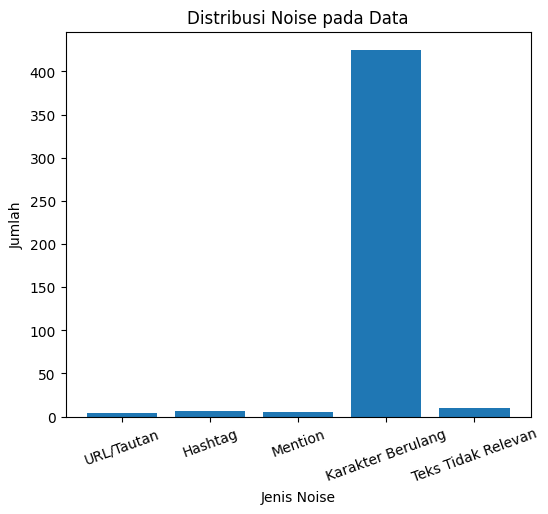

In [16]:
noise_summary = {
    'URL/Tautan': df['contains_url'].sum(),
    'Hashtag': df['contains_hashtag'].sum(),
    'Mention': df['contains_mention'].sum(),
    #'Emoji': df['contains_emoji'].sum(),
    #'Simbol': df['contains_symbol'].sum(),
    'Karakter Berulang': df['contains_repeated_char'].sum(),
    'Teks Tidak Relevan': df['irrelevant_text'].sum()
}

noise_df = pd.DataFrame(
    noise_summary.items(),
    columns=['Jenis Noise', 'Jumlah']
)

print("\n===== RINGKASAN NOISE =====")
print(noise_df)

# Visualisasi Noise
plt.figure(figsize=(6,5))
plt.bar(noise_df['Jenis Noise'], noise_df['Jumlah'])
plt.title('Distribusi Noise pada Data')
plt.xlabel('Jenis Noise')
plt.ylabel('Jumlah')
plt.xticks(rotation=20)
plt.show()

#PREPROCESSING

---



In [17]:
#copy dataset, agar data asli tidak berubah
clean_df = df.copy()

##Case Folding

In [18]:
clean_df['clean_text'] = clean_df['komen_fb'].str.lower()
print(clean_df[['clean_text']].head())

                                          clean_text
0                     tuntutan dalam 7 hari kedepan:
1  kalau ada pejabat yg  korupsi, jangan harap lg...
2  para pejabat publik sering pamer harta benda, ...
3  drpada fasilitas umum dan pertokoan ya mending...
4            hahaha  it's hilarious, rampok dirampok


##Noise Removal

In [19]:
import re

def clean_noise(text):

    text = str(text)

    #hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    #hapus hashtag
    text = re.sub(r'#', '', text)

    #hapus mention
    text = re.sub(r'@', '', text)

    #hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

clean_df['clean_text'] = clean_df['clean_text'].apply(clean_noise)

##Normalisasi

Ubah Karakter Berulang

In [20]:
def normalize_repeated_char(word):

    word = re.sub(r'(.)\1{2,}', r'\1', word)

    return word


def normalize_text(text):

    words = text.split()

    normalized_words = [
        normalize_repeated_char(word)
        for word in words
    ]

    return ' '.join(normalized_words)

clean_df['clean_text'] = clean_df['clean_text'].apply(normalize_text)
print(clean_df[['clean_text']].head())

                                          clean_text
0                     tuntutan dalam 7 hari kedepan:
1  kalau ada pejabat yg korupsi, jangan harap lgi...
2  para pejabat publik sering pamer harta benda, ...
3  drpada fasilitas umum dan pertokoan ya mending...
4             hahaha it's hilarious, rampok dirampok


##Cleaning Data

Hapus Teks tidak Relevan

In [21]:
def irrelevant_text(text):

    # Tangani missing value terlebih dahulu
    if pd.isna(text):
        return False      # biarkan NaN, akan dihapus pada langkah terakhir

    text = str(text).strip()

    # Terlalu pendek
    if len(text) < 3:
        return True

    # Hanya simbol atau angka
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

clean_df = clean_df[
    ~clean_df['clean_text'].apply(irrelevant_text)
]

print("Jumlah data setelah hapus text irrelevant:")
print(len(clean_df))

Jumlah data setelah hapus text irrelevant:
13624


Hapus Duplikat Data

In [22]:
clean_df = clean_df.drop_duplicates(subset=['clean_text'])

print("\nJumlah data setelah hapus duplikat:")
print(len(clean_df))


Jumlah data setelah hapus duplikat:
12805


Hapus Missing Value

In [23]:
clean_df = clean_df.dropna(subset=['clean_text'])

print("\nJumlah data setelah hapus missing value:")
print(len(clean_df))


Jumlah data setelah hapus missing value:
12805


#HASIL

In [24]:
print("\n===== HASIL PREPROCESSING =====")

print(clean_df[['komen_fb', 'clean_text']].head(10))

print("\nJumlah data akhir:")
print(len(clean_df))


===== HASIL PREPROCESSING =====
                                            komen_fb  \
0                     Tuntutan dalam 7 HARI KEDEPAN:   
1  Kalau ada pejabat yg  KORUPSI, Jangan harap lg...   
2  Para pejabat publik sering pamer harta benda, ...   
3  Drpada fasilitas umum dan pertokoan ya mending...   
4            Hahaha  it's hilarious, rampok dirampok   
5  Mungkin caranya salah, tapi tidak ada cara lai...   
6  Misi demo sudah melenceng. Kenapa mesti pakai ...   
7  Ini lah akibat dpr yg korup tidak mampu mewuju...   
8  the real perampasan aset versi rakyat, mungkin...   
9  Demo adalah hak setiap warga negara, tapi meno...   

                                          clean_text  
0                     tuntutan dalam 7 hari kedepan:  
1  kalau ada pejabat yg korupsi, jangan harap lgi...  
2  para pejabat publik sering pamer harta benda, ...  
3  drpada fasilitas umum dan pertokoan ya mending...  
4             hahaha it's hilarious, rampok dirampok  
5  mungkin caranya s

#SIMPAN HASIL

In [25]:
import os

final_df = clean_df[['clean_text']].copy()

# ubah nama kolom
final_df.columns = ['fb_clean']

In [26]:
folder_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Clean data'

os.makedirs(folder_path, exist_ok=True)

Simpan ke gdrive

In [27]:
output_path = f'{folder_path}/fb_clean.csv'

final_df.to_csv(output_path, index=False)

print("File berhasil disimpan di:")
print(output_path)

File berhasil disimpan di:
/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Clean data/fb_clean.csv


Download

In [28]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#DISTRIBUSI JUMLAH KATA TIAP KOMENTAR

---



In [29]:
# ======================================
# Distribusi Panjang Komentar
# ======================================

# Hitung jumlah kata pada setiap komentar
clean_df['word_count'] = clean_df['clean_text'].apply(
    lambda x: len(str(x).split())
)

# Hitung jumlah komentar pada setiap rentang
less_50 = (clean_df['word_count'] < 50).sum()
between_50_99 = ((clean_df['word_count'] >= 50) & (clean_df['word_count'] < 100)).sum()
between_100_199 = ((clean_df['word_count'] >= 100) & (clean_df['word_count'] < 200)).sum()
more_equal_200 = (clean_df['word_count'] >= 200).sum()

total = len(clean_df)

print("Distribusi Panjang Komentar")
print("="*40)
print(f"< 50 kata      : {less_50} komentar ({less_50/total*100:.2f}%)")
print(f"50-99 kata     : {between_50_99} komentar ({between_50_99/total*100:.2f}%)")
print(f"100-199 kata   : {between_100_199} komentar ({between_100_199/total*100:.2f}%)")
print(f"≥ 200 kata     : {more_equal_200} komentar ({more_equal_200/total*100:.2f}%)")

Distribusi Panjang Komentar
< 50 kata      : 12317 komentar (96.19%)
50-99 kata     : 439 komentar (3.43%)
100-199 kata   : 45 komentar (0.35%)
≥ 200 kata     : 4 komentar (0.03%)
